#### Prepared for Gabor's Data Analysis

### Data Analysis for Business, Economics, and Policy
by Gabor Bekes and  Gabor Kezdi
 
Cambridge University Press 2021

**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.


### Chapter 24
**CH24A Estimating the effect of the 2010 Haiti earthquake on GDP**

using the `haiti-earthquake` dataset

version 1.0 2021-05-05

In [1]:
import os
import sys
import warnings
from datetime import datetime as dt

import numpy as np
import pandas as pd
from plotnine import *

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


warnings.filterwarnings("ignore")
# turning off scientific notation
pd.set_option("display.float_format", lambda x: "%.3f" % x)


In [2]:
data = pd.read_stata("/workspaces/codespaces-jupyter/data/haiti-earthquake-mod.dta")
# data = pd.read_stata("https://osf.io/download/h5yjm/")

In [3]:
dp_countries = [
    "Benin",
    "Burkina Faso",
    "Burundi",
    "Bangladesh",
    "Cambodia",
    "Cameroon",
    "Kenya",
    "Kyrgyz Repub"
    "lic",
    "Liberia",
    "Madagascar",
    "Mali",
    "Moldova",
    "Mozambique",
    "Nicaragua",
    "Nepal",
    "Rwanda",
    "Senegal",
    "Sierra Leone",
    "Sudan",
    "Tanzania",
    "Togo",
    "Uganda",
    "Haiti",
]



In [4]:
data = data.loc[lambda x: x["country"].isin(dp_countries)]


In [5]:
haiti = data.loc[lambda x: x["country"] == "Haiti", ["year", "gdptb_us"]].reset_index(
    drop=True
)
haiti

,year,gdptb_us
0,2004,6.267
1,2005,6.379
2,2006,6.523
3,2007,6.741
4,2008,6.798
5,2009,7.008
6,2010,6.623
7,2011,6.988
8,2012,7.190
9,2013,7.495


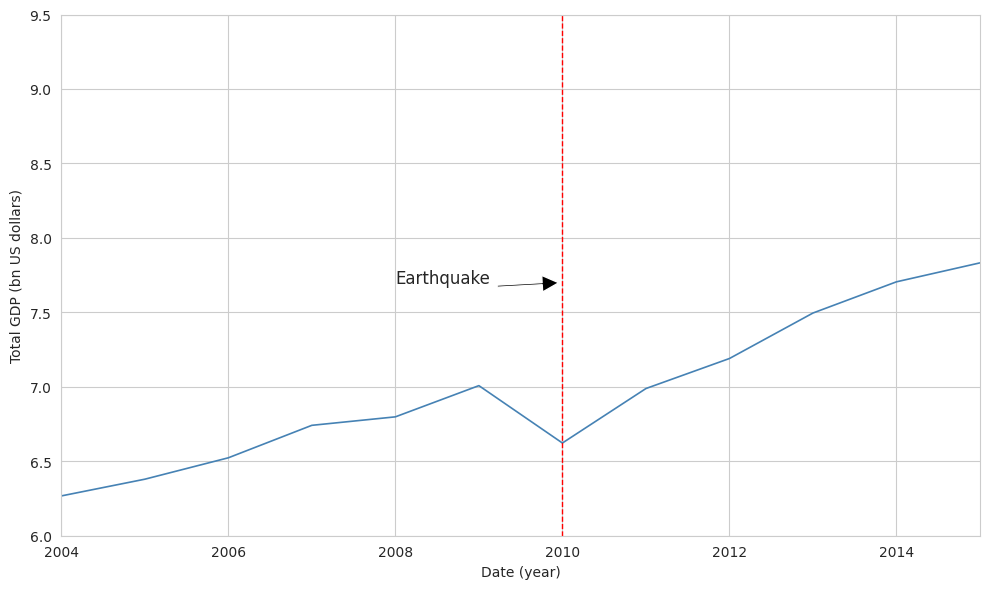

In [6]:
sns.set_style('whitegrid')

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot GDP over time
ax.plot(haiti['year'], haiti['gdptb_us'], linewidth=1.2, color='steelblue')

# Add vertical line for earthquake
ax.axvline(x=2010, color='red', linestyle='dashed', linewidth=1)

# Add arrow and label
ax.annotate('Earthquake', xy=(2010, 7.7), xytext=(2008, 7.7),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
            fontsize=12)

# Set axis labels and limits
ax.set_xlabel('Date (year)')
ax.set_ylabel('Total GDP (bn US dollars)')
ax.set_ylim(6, 9.5)
ax.set_xlim(2004, 2015)
ax.set_xticks(np.arange(2004, 2016, 2))
ax.set_yticks(np.arange(6, 10, 0.5))

plt.tight_layout()


**NOTE:** To install the [SyntheticControlMethods](https://github.com/OscarEngelbrektson/SyntheticControlMethods) package, you have to have CMake installed on your computer (at least for Mac OS, we needed it). Follow the instructions on the CMake [website](https://cmake.org/)

In [7]:
%pip install SyntheticControlMethods
from SyntheticControlMethods import Synth

Note: you may need to restart the kernel to use updated packages.


In [10]:
%pip install syntheticcontrol

ERROR: Could not find a version that satisfies the requirement syntheticcontrol (from versions: none)
ERROR: No matching distribution found for syntheticcontrol
Note: you may need to restart the kernel to use updated packages.


In [8]:
data = data.filter(
    [
        "country",
        "year",
        "gdptb_us",
        "cons",
        "exp",
        "imp",
        "gcf",
        "land",
        "pop",
        "inf",
        "gdppc_w",
    ]
)

In [12]:
data

,country,year,gdptb_us,cons,exp,imp,gcf,land,pop,inf,gdppc_w
180,Bangladesh,2004,80.593,79.573,11.147,15.712,24.992,130170.000,140843792.000,7.588,1844.816
181,Bangladesh,2005,85.860,79.781,14.393,20.004,25.830,130170.000,142929984.000,7.047,1936.705
182,Bangladesh,2006,91.589,79.261,16.353,21.758,26.144,130170.000,144839232.000,6.765,2038.687
183,Bangladesh,2007,98.054,79.773,16.995,22.947,26.178,130170.000,146592688.000,9.107,2156.484
184,Bangladesh,2008,104.000,81.101,17.659,24.962,26.202,130170.000,148252480.000,8.902,2260.575
...,...,...,...,...,...,...,...,...,...,...,...
2431,Uganda,2011,22.134,87.587,18.937,33.775,27.251,200520.000,34260344.000,18.693,1648.531
2432,Uganda,2012,23.110,85.823,20.126,32.972,27.024,200520.000,35400620.000,14.016,1665.809
2433,Uganda,2013,23.866,82.054,20.246,30.520,28.220,200520.000,36573388.000,5.464,1665.130
2434,Uganda,2014,25.016,82.630,18.370,28.456,27.456,200520.000,37782972.000,4.288,1689.437


In [9]:
sc = Synth(
    data,           # your full DataFrame
    "gdptb_us",     # outcome variable
    "country",      # unit identifier (treated vs control)
    "year",         # time identifier
    2010,           # treatment year
    "Haiti",        # treated unit
    pen=0,         # penalty (regularization)
    n_optim=200,    # number of optimization restarts
    random_seed=210
)

In [23]:
sc = Synth(
    data,
    "gdptb_us",
    "country",
    "year",
    2010,
    "Haiti",
    pen=0,
    n_optim=200,
    random_seed=210
)

ValueError: 'x0' must only have one dimension.

Built-in plots for comparison

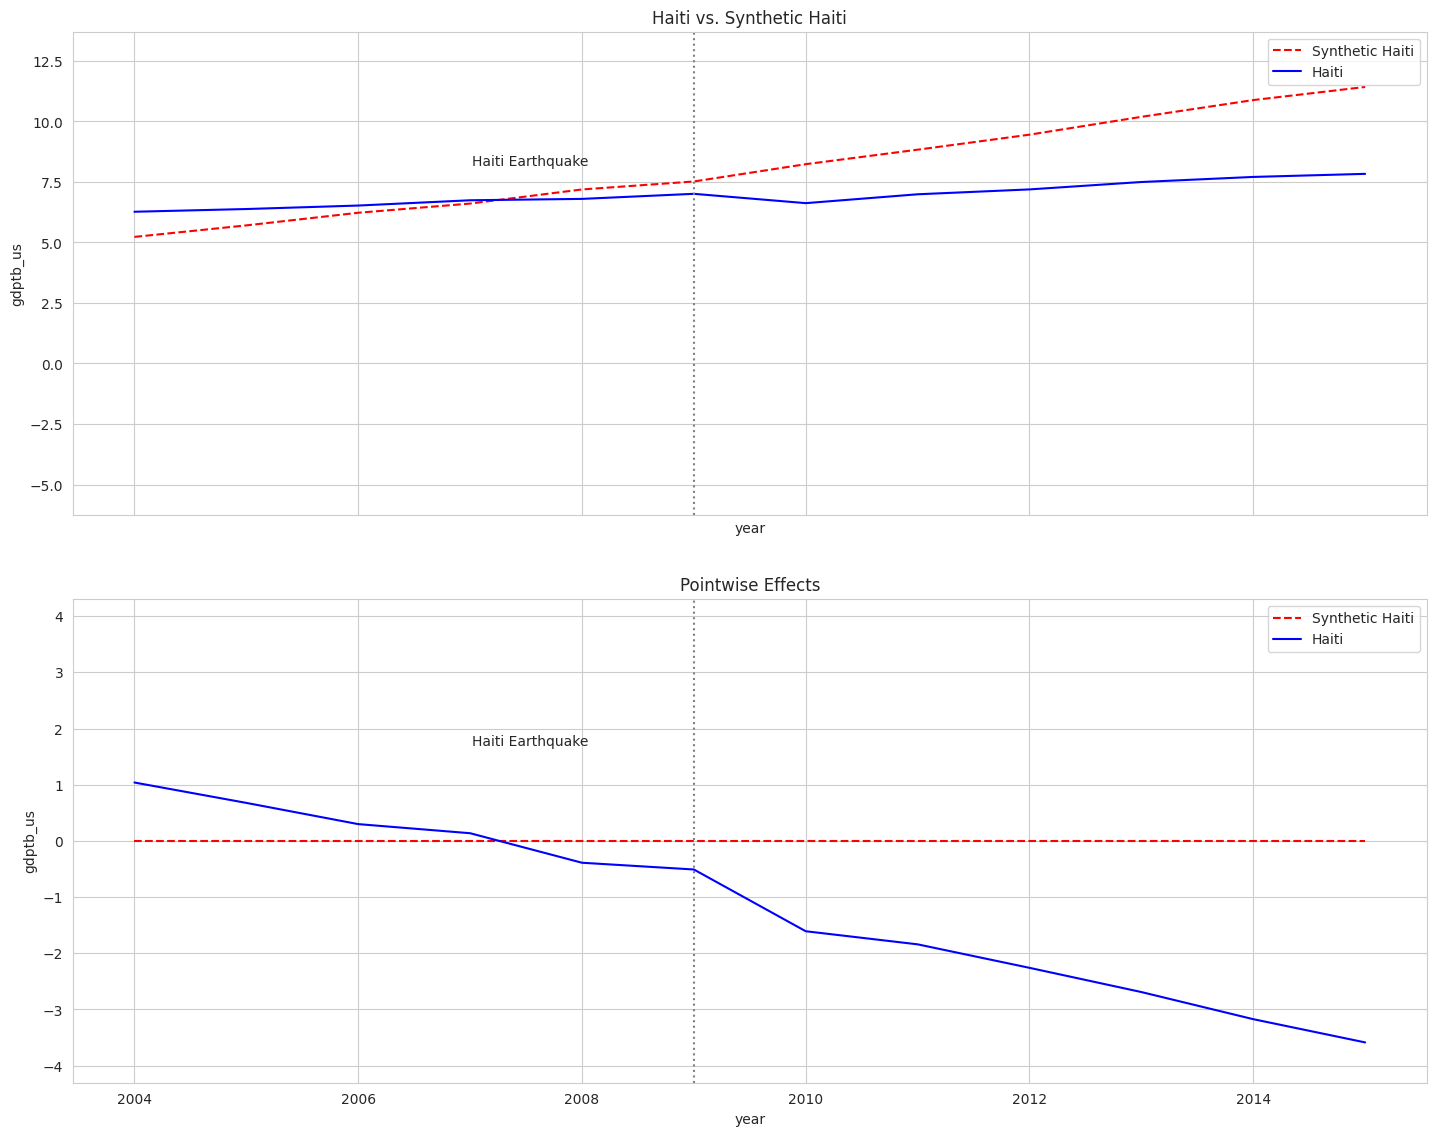

In [10]:
sc.plot(
    ["original", "pointwise"],
    treated_label="Haiti",
    synth_label="Synthetic Haiti",
    treatment_label="Haiti Earthquake",
)


Get weight matrix of solution


In [11]:
sc.original_data.weight_df

,Weight
Mali,0.497
Moldova,0.503


In [12]:
sc.original_data.comparison_df

,Haiti,Synthetic Haiti,WMAPE,Importance
gdptb_us,6.620,6.410,1.200,0.040
cons,100.200,98.590,12.660,0.320
exp,14.260,34.930,20.670,0.000
imp,42.950,60.570,27.980,0.080
gcf,28.490,27.050,4.710,0.020
land,27560.000,623269.270,595709.270,0.040
pop,9484519.000,8542558.070,4992238.120,0.030
inf,12.610,6.690,5.920,0.270
gdppc_w,1582.400,2465.760,1051.350,0.190


**NOTE:** This algorithm results in a different weights for the Synthetic Haiti than Stata

Get synthetic outcomes for Haiti

In [13]:
haiti["Ysynthetic"] = sc.original_data.__dict__["synth_outcome"][0]
haiti["Ytreated"] = haiti["gdptb_us"]

Figure with total GDP in Haiti and synthethic control

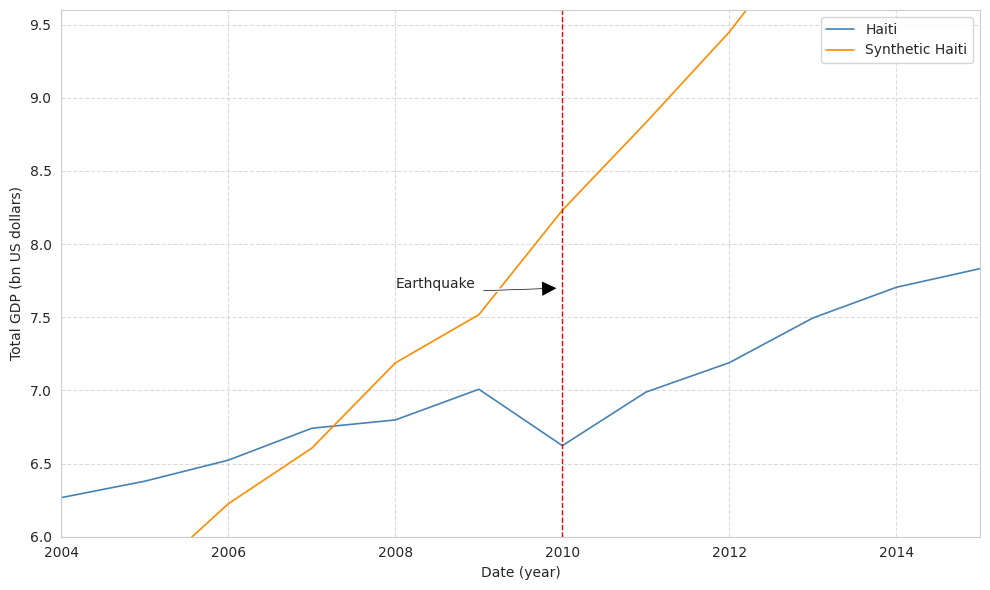

In [14]:
# Define colors
color = ['steelblue', 'darkorange', 'red', 'green', 'gray']

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot actual Haiti GDP
ax.plot(haiti['year'], haiti['Ytreated'], 
    color=color[0], linewidth=1.2, label='Haiti')

# Plot synthetic control Haiti GDP
ax.plot(haiti['year'], haiti['Ysynthetic'], 
    color=color[1], linewidth=1.2, label='Synthetic Haiti')

# Add vertical line for earthquake
ax.axvline(x=2010, color=color[2], linestyle='dashed', linewidth=1)

# Add arrow and label for earthquake
ax.annotate('Earthquake', 
        xy=(2010, 7.7), 
        xytext=(2008, 7.7),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
        fontsize=10)

# Set axis labels and formatting
ax.set_xlabel('Date (year)')
ax.set_ylabel('Total GDP (bn US dollars)')
ax.set_ylim(6, 9.6)
ax.set_xlim(2004, 2015)
ax.set_xticks(range(2004, 2016, 2))
ax.set_yticks(np.arange(6, 10, 0.5))

# Add legend
ax.legend()

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()


 Figure with differenence in log total GDP

In [ ]:
(
    ggplot(haiti, aes(x="year", y="np.log(Ytreated) - np.log(Ysynthetic)"))
    + geom_line(color=color[0], size=1.2)
    + geom_vline(xintercept=2010, color=color[2], size=1, linetype="dashed")
    + geom_hline(yintercept=0, color=color[4], size=1.2)
    + labs(y="Effect estimate, ln(bn US dollars)", x="Date (year)")
    + geom_segment(
        aes(x=2009, y=-0.17, xend=2010, yend=-0.17),
        arrow=arrow(type="closed", ends="last"),
    )
    + annotate("text", x=2008, y=-0.17, label="Earthquake", size=10)
    + scale_y_continuous(breaks=seq(-0.2, 0.06, 0.05), limits=(-0.20, 0.05))
    + scale_x_continuous(breaks=seq(2004, 2015, 2), limits=(2004, 2015))
    + theme_bw()
)
